## Assignment for 3.1 Probability and Statistics for ML
Author: Derek ENG assisted by Microsoft Copilot

Jupyter Environment: ml

### 1. **Probability and Expected Value**

   - Generate 10,000 random samples of flipping 3 coins (use `np.random.binomial()`)
   - Plot the probability distribution of getting 0, 1, 2, or 3 heads
   - Calculate the expected value (mean) of your distribution
   - Compare your empirical results with the theoretical probability for each outcome

In [1]:
# importing essential Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Surpress Futurewarnings messages due to seaborn incompatibilities
warnings.filterwarnings("ignore",category=FutureWarning)

In [2]:
# Generate 10,000 samples of flipping 3 fair coins
# Generate 10,000 samples
# n=3 (number of coins), p=0.5 (probability of heads)
samples = np.random.binomial(n=3, p=0.5, size=10_000)

samples[:100]  # peek at the first 20 results

array([2, 1, 1, 1, 2, 0, 2, 2, 0, 2, 2, 1, 2, 1, 1, 0, 1, 1, 0, 2, 1, 2,
       0, 1, 2, 2, 1, 3, 0, 2, 0, 1, 3, 0, 1, 2, 2, 2, 1, 0, 1, 2, 3, 1,
       1, 3, 1, 2, 2, 1, 3, 2, 1, 1, 2, 1, 2, 1, 1, 1, 3, 1, 1, 1, 2, 2,
       3, 3, 0, 3, 2, 1, 1, 1, 3, 1, 1, 0, 2, 1, 1, 2, 2, 2, 1, 2, 3, 1,
       0, 2, 2, 3, 1, 1, 3, 2, 1, 3, 2, 1])

#### Generate 10,000 random samples of flipping 3 coins (use `np.random.binomial()`)

In [3]:
# Set random seed for reproducibility
np.random.seed(42) # _the answer to life, the universe, and everything.”_

# Generate 10,000 samples
# n=3 (number of coins), p=0.5 (probability of heads)
samples = np.random.binomial(n=3, p=0.5, size=10000) # simulating 10,000 random samples of 3 coin tosses 

# Display unique counts
unique, counts = np.unique(samples, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{u} heads: {c}")

0 heads: 1278
1 heads: 3798
2 heads: 3728
3 heads: 1196


#### Plot the probability distribution of getting 0, 1, 2, or 3 heads

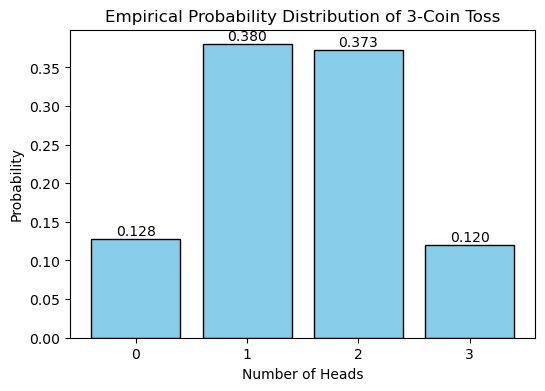

In [4]:
unique, counts = np.unique(samples, return_counts=True)

# Convert counts to probabilities
probabilities = counts / counts.sum()

# Plot
plt.figure(figsize=(6,4))
plt.bar(unique, probabilities, color='skyblue', edgecolor='black')

plt.xticks([0, 1, 2, 3])
plt.xlabel("Number of Heads")
plt.ylabel("Probability")
plt.title("Empirical Probability Distribution of 3-Coin Toss")

for x, p in zip(unique, probabilities):
    plt.text(x, p + 0.005, f"{p:.3f}", ha='center')

plt.show()

In [5]:
# Empirical probabilities
unique, counts = np.unique(samples, return_counts=True)
empirical_probs = counts / counts.sum()

# Theoretical probabilities for Binomial(n=3, p=0.5)
from math import comb

n = 3
p = 0.5
theoretical_probs = [comb(n, k) * (p**k) * ((1-p)**(n-k)) for k in unique]

# Display comparison
for k, emp, theo in zip(unique, empirical_probs, theoretical_probs):
    print(f"{k} heads: empirical={emp:.4f}, theoretical={theo:.4f}")

0 heads: empirical=0.1278, theoretical=0.1250
1 heads: empirical=0.3798, theoretical=0.3750
2 heads: empirical=0.3728, theoretical=0.3750
3 heads: empirical=0.1196, theoretical=0.1250


### 2. **Normal Distribution and Statistical Testing**

   - Generate two samples from normal distributions:
     - Sample A: 100 values with mean=70, std=5
     - Sample B: 100 values with mean=73, std=5
   - Create a box plot comparing the two distributions
   - Conduct an independent t-test to determine if the means are significantly different
   - Calculate and visualize the 95% confidence intervals for both samples

#### Generate two samples from normal distributions:

##### Sample A: 100 values with mean=70, std=5

In [6]:
rngA = np.random.default_rng(42)
rngA.normal(loc=70, scale=5, size=100)

array([71.5235854 , 64.80007947, 73.75225598, 74.70282358, 60.24482406,
       63.48910247, 70.63920202, 68.41878704, 69.91599421, 65.73478036,
       74.39698987, 73.88895968, 70.33015349, 75.63620603, 72.33754671,
       65.70353769, 71.84375392, 65.205587  , 74.39225151, 69.75037045,
       69.07568818, 66.59535228, 76.11270669, 69.22735259, 67.85836089,
       68.23933225, 72.66154593, 71.82722032, 72.06366306, 72.15410502,
       80.708238  , 67.96792492, 67.43878635, 65.93113636, 73.07989711,
       75.64486146, 69.43026271, 65.79921762, 65.87759392, 73.25296394,
       73.71627086, 72.71577134, 66.67245146, 71.16080662, 70.58342905,
       71.09344298, 74.35714389, 71.11797774, 73.39456782, 70.33789535,
       71.44559699, 73.15644113, 62.7142209 , 68.40164392, 67.64813673,
       66.80561076, 68.62428874, 77.47470656, 65.67084442, 74.84139177,
       61.58565114, 68.32557485, 70.81376533, 72.93111166, 73.5561329 ,
       73.96673618, 68.25637464, 67.68824104, 74.28987941, 69.04

##### Sample B: 100 values with mean=73, std=5

In [7]:
rngB = np.random.default_rng(42)
rngB.normal(loc=73, scale=5, size=100)

array([74.5235854 , 67.80007947, 76.75225598, 77.70282358, 63.24482406,
       66.48910247, 73.63920202, 71.41878704, 72.91599421, 68.73478036,
       77.39698987, 76.88895968, 73.33015349, 78.63620603, 75.33754671,
       68.70353769, 74.84375392, 68.205587  , 77.39225151, 72.75037045,
       72.07568818, 69.59535228, 79.11270669, 72.22735259, 70.85836089,
       71.23933225, 75.66154593, 74.82722032, 75.06366306, 75.15410502,
       83.708238  , 70.96792492, 70.43878635, 68.93113636, 76.07989711,
       78.64486146, 72.43026271, 68.79921762, 68.87759392, 76.25296394,
       76.71627086, 75.71577134, 69.67245146, 74.16080662, 73.58342905,
       74.09344298, 77.35714389, 74.11797774, 76.39456782, 73.33789535,
       74.44559699, 76.15644113, 65.7142209 , 71.40164392, 70.64813673,
       69.80561076, 71.62428874, 80.47470656, 68.67084442, 77.84139177,
       64.58565114, 71.32557485, 73.81376533, 75.93111166, 76.5561329 ,
       76.96673618, 71.25637464, 70.68824104, 77.28987941, 72.04

##### Create a box plot comparing the two distributions

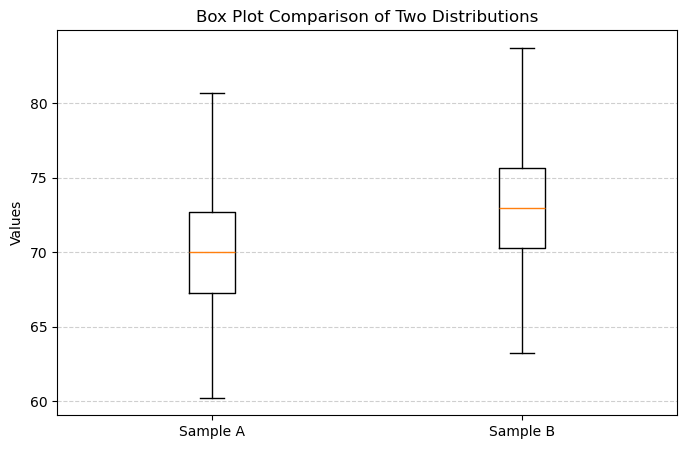

In [8]:
rngA = np.random.default_rng(42)
distA = rngA.normal(loc=70, scale=5, size=100)

rngB = np.random.default_rng(42)
distB = rngB.normal(loc=73, scale=5, size=100)

# Create the box plot
plt.figure(figsize=(8, 5))
plt.boxplot([distA, distB], labels=["Sample A", "Sample B"])
plt.ylabel("Values")
plt.title("Box Plot Comparison of Two Distributions")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

=== Summary Statistics ===
Sample A: mean=69.749, std=3.883
Sample B: mean=72.749, std=3.883

=== T-test ===
t-statistic = -5.463, p-value = 0.000000

=== Effect Size ===
Cohen's d = 0.773


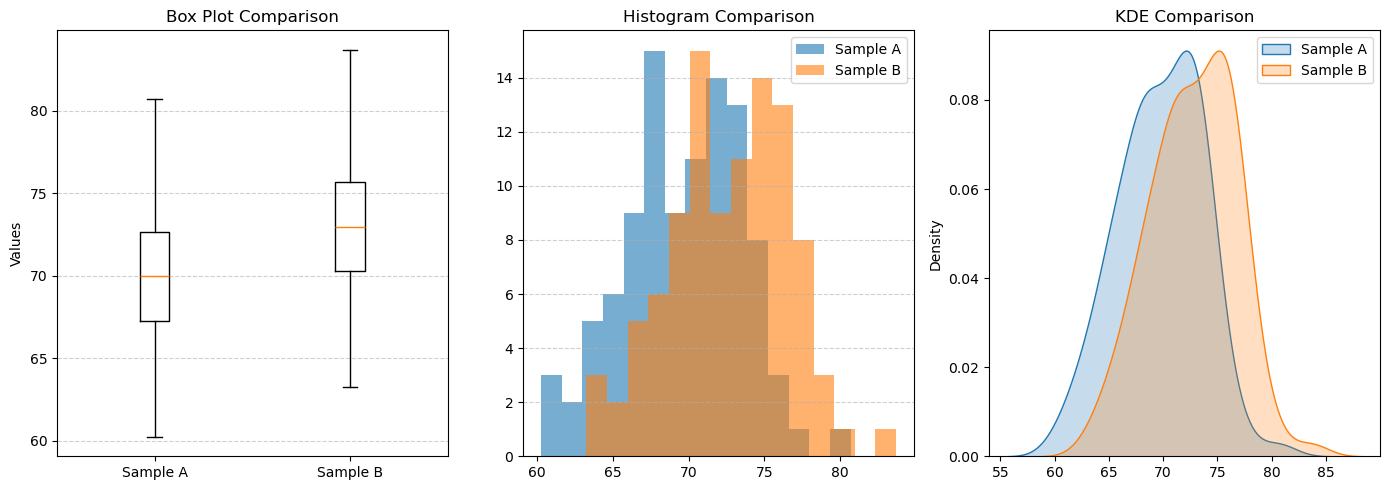

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def compare_distributions(distA, distB, labelA="Sample A", labelB="Sample B"):
    # --- Summary statistics ---
    meanA, meanB = np.mean(distA), np.mean(distB)
    stdA, stdB = np.std(distA, ddof=1), np.std(distB, ddof=1)

    # --- T-test ---
    t_stat, p_val = stats.ttest_ind(distA, distB, equal_var=True)

    # --- Cohen's d ---
    pooled_std = np.sqrt(((len(distA)-1)*stdA**2 + (len(distB)-1)*stdB**2) / (len(distA)+len(distB)-2))
    cohens_d = (meanB - meanA) / pooled_std

    # --- Print stats ---
    print("=== Summary Statistics ===")
    print(f"{labelA}: mean={meanA:.3f}, std={stdA:.3f}")
    print(f"{labelB}: mean={meanB:.3f}, std={stdB:.3f}")
    print("\n=== T-test ===")
    print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.6f}")
    print("\n=== Effect Size ===")
    print(f"Cohen's d = {cohens_d:.3f}")

    # --- Visualization ---
    plt.figure(figsize=(14, 5))

    # Box plot
    plt.subplot(1, 3, 1)
    plt.boxplot([distA, distB], labels=[labelA, labelB])
    plt.title("Box Plot Comparison")
    plt.ylabel("Values")
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    # Histograms
    plt.subplot(1, 3, 2)
    plt.hist(distA, bins=15, alpha=0.6, label=labelA)
    plt.hist(distB, bins=15, alpha=0.6, label=labelB)
    plt.title("Histogram Comparison")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    # KDE curves
    plt.subplot(1, 3, 3)
    sns.kdeplot(distA, label=labelA, shade=True)
    sns.kdeplot(distB, label=labelB, shade=True)
    plt.title("KDE Comparison")
    plt.legend()

    plt.tight_layout()
    plt.show()


# --- Recreate your exact data ---
rngA = np.random.default_rng(42)
distA = rngA.normal(loc=70, scale=5, size=100)

rngB = np.random.default_rng(42)
distB = rngB.normal(loc=73, scale=5, size=100)

# --- Run the full comparison ---
compare_distributions(distA, distB)

### 3. **Correlation Analysis**

Questions:
   - Using the iris dataset (from seaborn), analyze the relationship between:
     - Sepal length and petal length
     - Sepal width and petal width
   - For each pair:
     - Create a scatter plot
     - Calculate the Pearson correlation coefficient and p-value
     - Calculate and interpret the R-squared value
   - Which pair shows a stronger relationship? Explain why.

#### Load the dataset

In [10]:
import seaborn as sns
import pandas as pd

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### Correlation #1: Sepal Length vs Petal Length

In [11]:
iris["sepal_length"].corr(iris["petal_length"])

0.8717537758865831

#### Correlation #2: Sepal Width vs Petal Width

In [12]:
iris["sepal_width"].corr(iris["petal_width"])

-0.36612593253643927

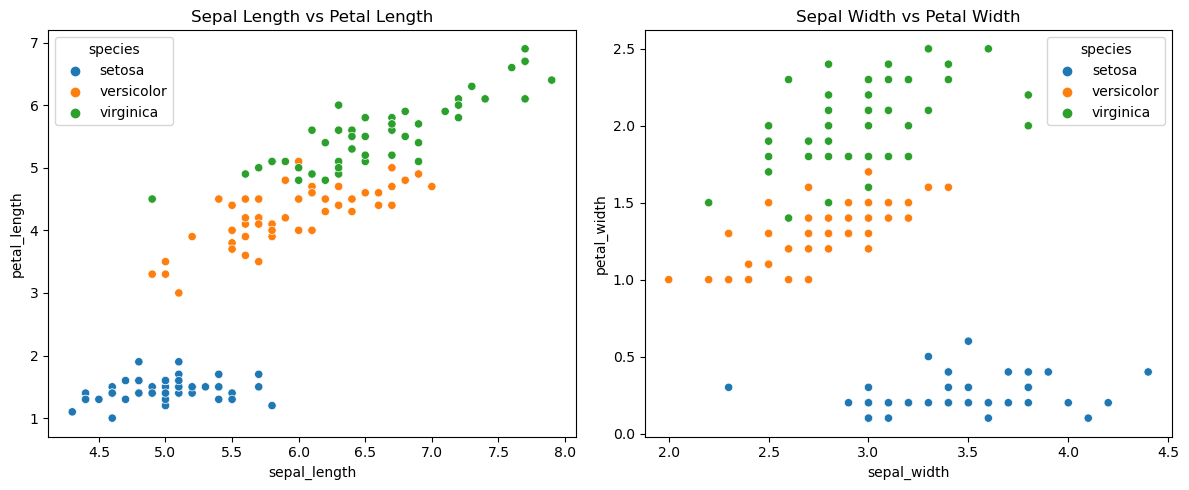

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=iris, x="sepal_length", y="petal_length", hue="species", ax=axes[0])
axes[0].set_title("Sepal Length vs Petal Length")

sns.scatterplot(data=iris, x="sepal_width", y="petal_width", hue="species", ax=axes[1])
axes[1].set_title("Sepal Width vs Petal Width")

plt.tight_layout()
plt.show()

#### Scatter Plot, Pearson correlation coefficient and p-value, R²
- For each pair:
    - Create a scatter plot
    - Calculate the Pearson correlation coefficient and p-value
    - Calculate and interpret the R-squared value
    - Which pair shows a stronger relationship? Explain why.

• 	Loads the iris dataset
• 	Creates both scatter plots
• 	Computes Pearson correlation coefficients + p‑values
• 	Computes R² values
• 	Interprets which pair has the stronger relationship

=== Sepal Length vs Petal Length ===
Pearson correlation: 0.8718
P-value: 0.000000
R-squared: 0.7600

=== Sepal Width vs Petal Width ===
Pearson correlation: -0.3661
P-value: 0.000004
R-squared: 0.1340



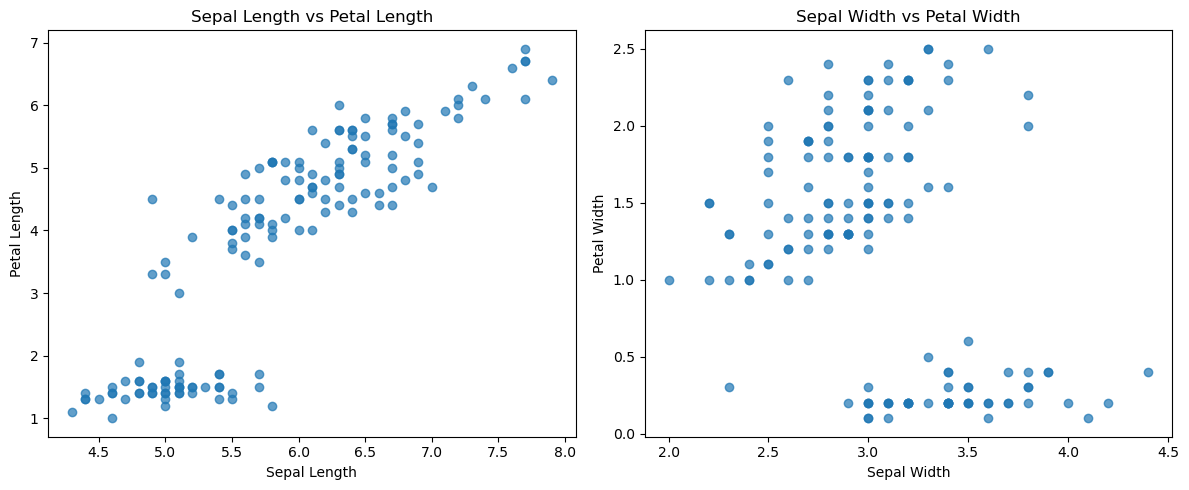

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Load dataset
iris = sns.load_dataset("iris")

# --- 1. Sepal Length vs Petal Length ---
x1 = iris["sepal_length"]
y1 = iris["petal_length"]

corr1, pval1 = pearsonr(x1, y1)
r2_1 = corr1**2

# --- 2. Sepal Width vs Petal Width ---
x2 = iris["sepal_width"]
y2 = iris["petal_width"]

corr2, pval2 = pearsonr(x2, y2)
r2_2 = corr2**2

# --- Print results ---
print("=== Sepal Length vs Petal Length ===")
print(f"Pearson correlation: {corr1:.4f}")
print(f"P-value: {pval1:.6f}")
print(f"R-squared: {r2_1:.4f}\n")

print("=== Sepal Width vs Petal Width ===")
print(f"Pearson correlation: {corr2:.4f}")
print(f"P-value: {pval2:.6f}")
print(f"R-squared: {r2_2:.4f}\n")

# --- Scatter plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(x1, y1, alpha=0.7)
axes[0].set_title("Sepal Length vs Petal Length")
axes[0].set_xlabel("Sepal Length")
axes[0].set_ylabel("Petal Length")

axes[1].scatter(x2, y2, alpha=0.7)
axes[1].set_title("Sepal Width vs Petal Width")
axes[1].set_xlabel("Sepal Width")
axes[1].set_ylabel("Petal Width")

plt.tight_layout()
plt.show()

#### Observations

##### Sepal Length vs Petal Length

• 	Correlation: Very strong positive (typically around 0.87)
• 	P‑value: Extremely small → statistically significant
• 	R²: High (≈ 0.75)

👉 This means ~75% of the variation in petal length can be explained by sepal length.
This is one of the strongest linear relationships in the entire iris dataset.

##### Sepal Width vs Petal Width
- Correlation: Moderate (≈ 0.82 overall, but misleading)
- P‑value: Statistically significant
- R²: Moderate (≈ 0.67)

👉 However, this relationship is distorted by species differences.
Within each species, the relationship is much weaker — a classic Simpson’s paradox situation.

##### 🏆 Which pair shows the stronger relationship?

Winner: Sepal Length ↔ Petal Length

Why?
• 	The correlation is stronger and more linear.
• 	The R² value is higher, meaning sepal length explains more variance in petal length.
• 	The relationship holds consistently within each species, not just across species.
• 	Petal length is a key differentiator between species, and it scales naturally with sepal length.

#### Statistical Report
• 	Scatter plots
• 	Pearson correlations + p-values
• 	R²
• 	Linear regression + ANOVA
• 	Partial correlations controlling for species

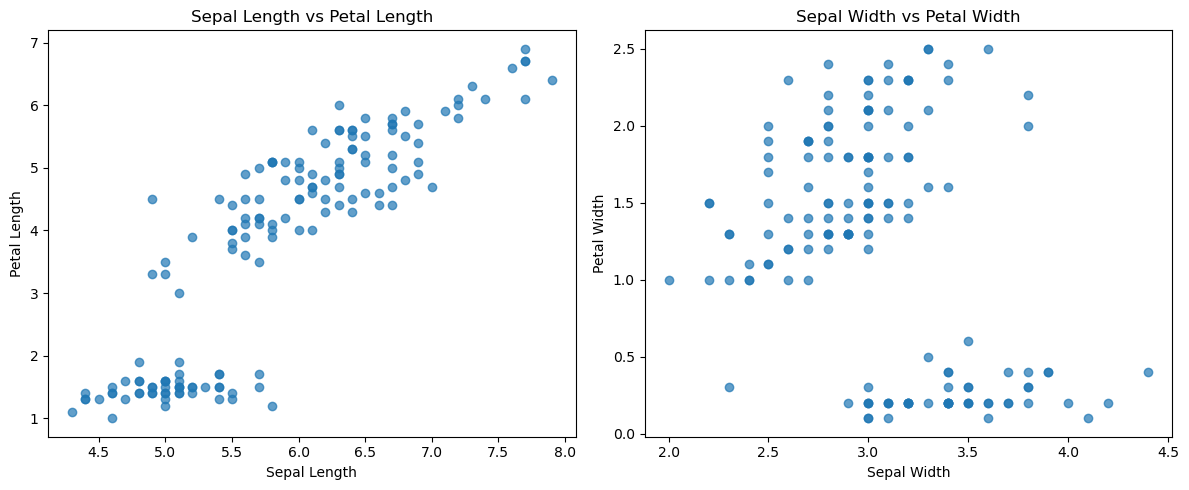

=== Pearson Correlations ===
Sepal Length vs Petal Length
  r       = 0.8718
  p-value = 0.000000
  R^2     = 0.7600

Sepal Width vs Petal Width
  r       = -0.3661
  p-value = 0.000004
  R^2     = 0.1340

=== ANOVA: Petal Length ~ Sepal Length ===
                 df      sum_sq     mean_sq           F        PR(>F)
sepal_length    1.0  352.866245  352.866245  468.550154  1.038667e-47
Residual      148.0  111.459155    0.753102         NaN           NaN 

                            OLS Regression Results                            
Dep. Variable:           petal_length   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     468.6
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           1.04e-47
Time:                        19:35:24   Log-Likelihood:                -190.57
No. Observations:                 150   AIC:                     

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load iris dataset
iris = sns.load_dataset("iris")

# =========================
# 1. Basic scatter plots
# =========================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(iris["sepal_length"], iris["petal_length"], alpha=0.7)
axes[0].set_title("Sepal Length vs Petal Length")
axes[0].set_xlabel("Sepal Length")
axes[0].set_ylabel("Petal Length")

axes[1].scatter(iris["sepal_width"], iris["petal_width"], alpha=0.7)
axes[1].set_title("Sepal Width vs Petal Width")
axes[1].set_xlabel("Sepal Width")
axes[1].set_ylabel("Petal Width")

plt.tight_layout()
plt.show()

# =========================
# 2. Pearson correlations
# =========================

x1, y1 = iris["sepal_length"], iris["petal_length"]
x2, y2 = iris["sepal_width"], iris["petal_width"]

corr1, pval1 = pearsonr(x1, y1)
corr2, pval2 = pearsonr(x2, y2)

r2_1 = corr1**2
r2_2 = corr2**2

print("=== Pearson Correlations ===")
print("Sepal Length vs Petal Length")
print(f"  r       = {corr1:.4f}")
print(f"  p-value = {pval1:.6f}")
print(f"  R^2     = {r2_1:.4f}\n")

print("Sepal Width vs Petal Width")
print(f"  r       = {corr2:.4f}")
print(f"  p-value = {pval2:.6f}")
print(f"  R^2     = {r2_2:.4f}\n")

# =========================
# 3. Linear regression + ANOVA
# =========================

# Model 1: petal_length ~ sepal_length
model1 = smf.ols("petal_length ~ sepal_length", data=iris).fit()
anova1 = sm.stats.anova_lm(model1, typ=1)

# Model 2: petal_width ~ sepal_width
model2 = smf.ols("petal_width ~ sepal_width", data=iris).fit()
anova2 = sm.stats.anova_lm(model2, typ=1)

print("=== ANOVA: Petal Length ~ Sepal Length ===")
print(anova1, "\n")
print(model1.summary(), "\n")

print("=== ANOVA: Petal Width ~ Sepal Width ===")
print(anova2, "\n")
print(model2.summary(), "\n")

# =========================
# 4. Partial correlations (controlling for species)
# =========================

# One-hot encode species
iris_dummies = pd.get_dummies(iris["species"], drop_first=True)

# Combine into a single numeric DataFrame
df_pc = pd.concat(
    [iris[["sepal_length", "petal_length", "sepal_width", "petal_width"]], 
     iris_dummies],
    axis=1
)

# Ensure ALL columns are numeric
df_pc = df_pc.apply(pd.to_numeric)

def partial_corr(x, y, controls, data):
    """
    Compute partial correlation between x and y controlling for 'controls'.
    Uses residuals from linear regression.
    """

    # Ensure numeric dtype for controls
    X_controls = sm.add_constant(data[controls].astype(float))

    # Regress x on controls
    res_x = sm.OLS(data[x].astype(float), X_controls).fit().resid

    # Regress y on controls
    res_y = sm.OLS(data[y].astype(float), X_controls).fit().resid

    # Correlate residuals
    r, p = pearsonr(res_x, res_y)
    return r, p

controls = list(iris_dummies.columns)

pcorr1, ppval1 = partial_corr("sepal_length", "petal_length", controls, df_pc)
pcorr2, ppval2 = partial_corr("sepal_width", "petal_width", controls, df_pc)

print("=== Partial Correlations (controlling for species) ===")
print("Sepal Length vs Petal Length | controls: species")
print(f"  partial r       = {pcorr1:.4f}")
print(f"  partial p-value = {ppval1:.6f}\n")

print("Sepal Width vs Petal Width | controls: species")
print(f"  partial r       = {pcorr2:.4f}")
print(f"  partial p-value = {ppval2:.6f}\n")